In [1]:
import cantera as ct
import matplotlib.pyplot as plt

In [2]:

mech_file = "gri30.yaml"
fuel_comp = {"CH4": 1.0}

# Inlet temperature in kelvin and inlet pressure in pascals
# In this case we are setting the inlet T and P to room temperature conditions
To = 300
Po = ct.one_atm

# Domain width in metres
width = 0.014

# Create the object representing the gas and set its state to match the inlet conditions
gas = ct.Solution(mech_file)


In [3]:
gas.TP = To, Po
gas.set_equivalence_ratio(1.0, fuel_comp, {"O2": 1.0, "N2": 3.76})


In [ ]:

flame = ct.FreeFlame(gas, width=width)
refine_criteria = flame.get_refine_criteria()
print("Default refinement criteria:")
print(refine_criteria)
flame.set_refine_criteria(ratio=3, slope=0.07, curve=0.14)

# ratio: Refines the grid if the spacing between adjacent grid points changes too rapidly.
# slope: Adds grid points where the normalized gradient (slope) of solution variables is large.
# curve: Adds points where the curvature (second derivative) is large.

flame.solve(loglevel=1, auto=True)

print(f"\nmixture-averaged flame speed = {flame.velocity[0]:7f} m/s\n")



************ Solving on 8 point grid with energy equation enabled ************

..............................................................................

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 2.136e-05  log(ss)= 5.493     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.0003649  log(ss)= 4.613     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.006235   log(ss)= 3.334     

Attempt Newton solution of steady-state problem.
Newton steady-state solve succeeded.

Problem solved on [9] point grid(s).
Expanding domain to accommodate flame thickness. New width: 0.028 m
##############################################################################
Refining grid in flame.
    New points inserted after grid points 0 1 2 3 4 5 6

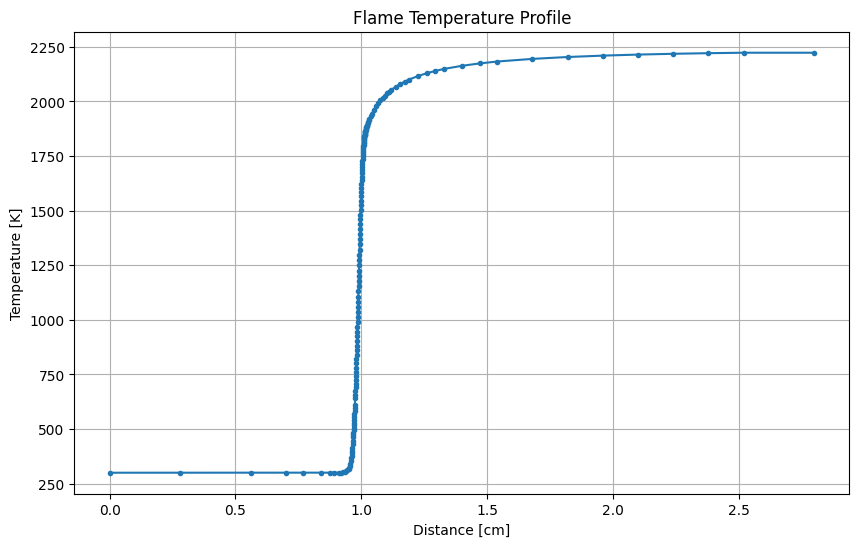

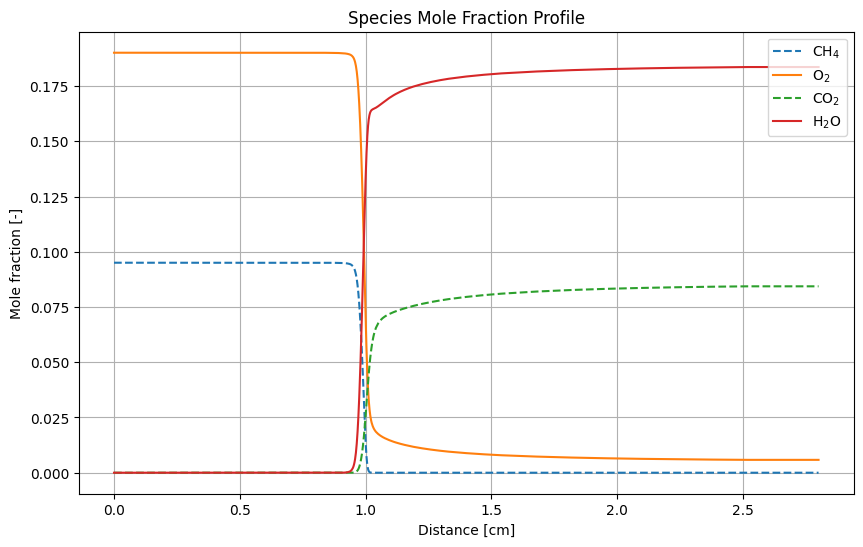

In [5]:
# Extract the spatial profiles as a SolutionArray to simplify plotting specific species
profile = flame.to_array()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(profile.grid * 100, profile.T, ".-")
ax.set_xlabel("Distance [cm]")
ax.set_ylabel("Temperature [K]")
ax.set_title("Flame Temperature Profile")
ax.grid()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(profile.grid * 100, profile("CH4").X, "--", label="CH$_4$")
ax.plot(profile.grid * 100, profile("O2").X, label="O$_2$")
ax.plot(profile.grid * 100, profile("CO2").X, "--", label="CO$_2$")
ax.plot(profile.grid * 100, profile("H2O").X, label="H$_2$O")

ax.legend(loc="best")
ax.set_xlabel("Distance [cm]")
ax.set_ylabel("Mole fraction [-]")
ax.set_title("Species Mole Fraction Profile")
ax.grid()
plt.show()